In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [25]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [27]:
#reading P2 continuous data
P5hobodf = pd.read_csv("P5_current.csv")
P5hobodf["Date-Time"] = pd.to_datetime(P5hobodf["Date-Time"])
P5date = P4hobodf["Date-Time"]
P5hobodfdate = P5date[1:]

In [28]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P5filteredtemp = hampel(P5hobodf["Temperature"], window_size=6, n_sigma=1.5)
P5filteredtempseries = pd.Series(P5filteredtemp.filtered_data, index = P5hobodf.index)
P5filteredtemp = P5filteredtempseries[1:]


In [29]:
#reading the manual data
P5mandf = pd.read_csv("P5ManualData.csv", index_col=False)
P5mandf.loc[:,"Temp bottom before"]
P5mandf["Date"] = pd.to_datetime(P5mandf["Date"])

In [30]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2Since2024.csv") #"NOAAHastingsDam2.csv" is a placeholder for the csv with your weather data
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

In [31]:
#reading C2 continuous data
C5hobodf = pd.read_csv("P5_creek_current.csv") 
C5hobodf["Date-Time"] = pd.to_datetime(C5hobodf["Date-Time"]) 
C5date = C5hobodf["Date-Time"]
C5hobodfdate = C5date[1:]

In [32]:
#filtering the C2 data for the outlier spikes where the hobo probe was removed from the piezometer
C5filteredhobo = hampel(C5hobodf["Temperature"], window_size=6, n_sigma=1.5)
C5filteredhoboseries = pd.Series(C5filteredhobo.filtered_data, index = C5hobodf.index)
C5filteredhobo = C5filteredhoboseries[1:]

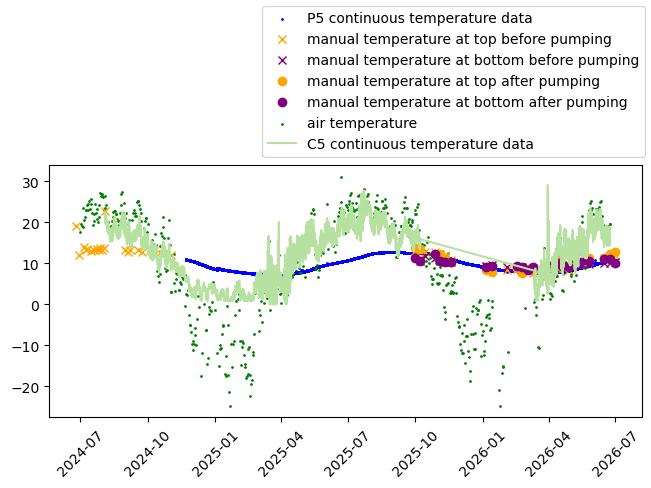

In [33]:
fig, ax = plt.subplots(layout='constrained')
plt.scatter(P5hobodfdate, P5filteredtemp, s = 1, color = "blue", label = "P5 continuous temperature data")
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime) and mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"]). 
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp bottom before"], 'x', color = "purple", label = "manual temperature at bottom before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"Temp bottom after"], 'o', color = "purple", label = "manual temperature at bottom after pumping")
plt.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], s = 1, color = "green", label = "air temperature")
# ax.scatter(C5hobodfdate, C5filteredhobo, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C5 continuous temperature data")
ax.plot(C5hobodfdate, C5filteredhobo, color = "xkcd:light grey green", label = "C5 continuous temperature data")
plt.xticks(rotation=45)
# plt.ylim((-5, 20))
# plt.xlim((pd.to_datetime("2026-02-18"), pd.to_datetime("2026-02-20")))

fig.legend(loc='outside upper right')
plt.show;

In [ ]:
#P5 specific conductivity

In [38]:
print(P5hobodf["Specific Conductivity"])

0        146.531219
1        483.975128
2        484.160583
3        484.273224
4        484.233643
            ...    
55598    661.993530
55599    662.026611
55600    661.796875
55601    661.845703
55602    673.502319
Name: Specific Conductivity, Length: 55603, dtype: float64


In [39]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P5filteredSPC = hampel(P5hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(P5filteredSPC.filtered_data)

0        146.531219
1        483.975128
2        484.160583
3        484.273224
4        484.233643
            ...    
55598    661.993530
55599    662.026611
55600    661.796875
55601    661.845703
55602    673.502319
Length: 55603, dtype: float32


In [40]:

P5filteredSPCseries = pd.Series(P5filteredSPC.filtered_data, index = P5hobodf.index)

P5filteredSPC = P5filteredSPCseries[1:]              #I used the google AI overview for this line of code :/

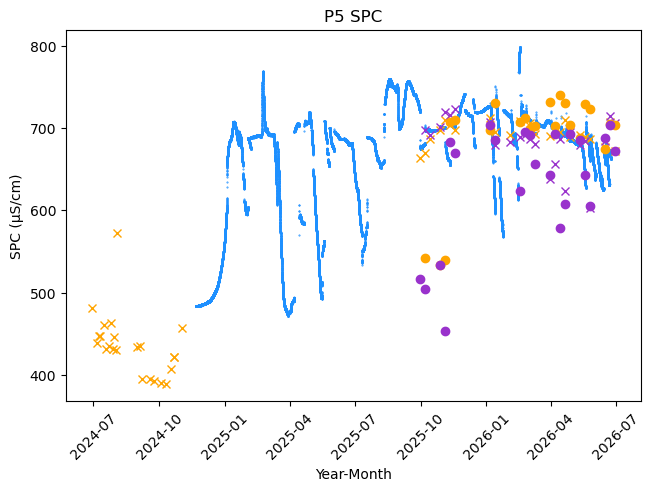

In [42]:

P5hobodate = P5hobodf["Date-Time"]
P5slicedhobodate = P5hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(P5slicedhobodate, P5filteredSPC, color="dodgerblue", s = 0.2, label = "HOBO continuous temperature")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P5 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()